In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('twitter_training.csv')
df.head()

,sn,platform,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [5]:
df.drop(['sn','platform'], axis=1)

,sentiment,text
0,Positive,im getting on borderlands and i will murder yo...
1,Positive,I am coming to the borders and I will kill you...
2,Positive,im getting on borderlands and i will kill you ...
3,Positive,im coming on borderlands and i will murder you...
4,Positive,im getting on borderlands 2 and i will murder ...
...,...,...
74677,Positive,Just realized that the Windows partition of my...
74678,Positive,Just realized that my Mac window partition is ...
74679,Positive,Just realized the windows partition of my Mac ...
74680,Positive,Just realized between the windows partition of...


In [6]:
df.describe()

,sn
count,74682.000000
mean,6432.586165
std,3740.427870
min,1.000000
25%,3195.000000
50%,6422.000000
75%,9601.000000
max,13200.000000


In [7]:
df.isnull().sum()

sn             0
platform       0
sentiment      0
text         686
dtype: int64

In [8]:
df['sentiment'].value_counts()

sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

In [9]:
df = df.dropna(subset=['text'])


In [10]:
label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
df['sentiment_label'] = df['sentiment'].map(label_map)

In [11]:
import spacy
nlp = spacy.load("en_core_web_sm")


In [12]:
import re

def basic_clean(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URLs
    text = re.sub(r"[^a-z\s]", "", text)        # remove emojis & punctuation
    return text


In [13]:
def preprocess_texts(texts):
    cleaned_texts = []

    texts = texts.str.lower()
    texts = texts.str.replace(r"http\S+|www\S+", "", regex=True)
    texts = texts.str.replace(r"[^a-z\s]", "", regex=True)

    for doc in nlp.pipe(texts, batch_size=1000, n_process=1):
        tokens = [
            token.lemma_
            for token in doc
            if not token.is_stop and not token.is_space
        ]
        cleaned_texts.append(" ".join(tokens))

    return cleaned_texts


In [14]:
df['clean_text'] = preprocess_texts(df['text'])


In [15]:
df[['text', 'clean_text']].sample(5)

,text,clean_text
57927,"Quick 4k,. <unk> w mixer.com/kn_blunt images.c...",quick k unk w mixercomknblunt imagescompbxyqeh...
71564,I'm liking this new update for,m like new update
68496,twitter.com/pcgamer/status…. 100 hour workweek...,twittercompcgamerstatus hour workweek pretty bad
15107,Dota Twenty Three best 20 strongest players in...,dota good strong player major esport esportsfo...
7383,I got made fun of for this I hate overwatch co...,get fun hate overwatch community pictwittercom...


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [17]:
tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.9
)


In [18]:
X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

In [19]:
print(X.shape)

(73996, 8000)


In [20]:
tfidf.get_feature_names_out()[:20]

array(['aa', 'aaa', 'aaron', 'ab', 'abandon', 'abandon sanction', 'abc',
       'ability', 'able', 'able load', 'able play', 'absolute',
       'absolute good', 'absolutely', 'absolutely amazing',
       'absolutely incredible', 'absolutely love', 'absurd', 'abt',
       'abuse'], dtype=object)

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

In [22]:
from sklearn.linear_model import LogisticRegression

LogisticRegressionmodel = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)

LogisticRegressionmodel.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)

In [23]:
from sklearn.metrics import accuracy_score

In [24]:
y_pred_LR = LogisticRegressionmodel.predict(X_test)


accuracy = accuracy_score(y_test, y_pred_LR)
print("Accuracy:", accuracy)

Accuracy: 0.7131756756756756


In [25]:

from sklearn.svm import LinearSVC

model_svc = LinearSVC()

model_svc.fit(X_train, y_train)

LinearSVC()

In [26]:
y_pred_svc = model_svc.predict(X_test)

accuracy_svc = accuracy_score(y_test, y_pred_svc)
print("Accuracy:", accuracy_svc)

Accuracy: 0.7534459459459459


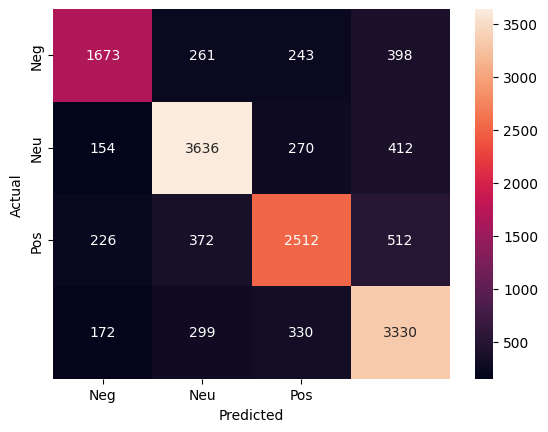

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svc)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Neg", "Neu", "Pos"],
            yticklabels=["Neg", "Neu", "Pos"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [30]:
from sklearn.pipeline import Pipeline
import joblib

pipeline = Pipeline([
    ("tfidf", tfidf),
    ("svm", model_svc)
])

joblib.dump(pipeline, "sentiment_pipeline.pkl")
print("Pipeline saved successfully")



Pipeline saved successfully


In [31]:
import os
print(os.listdir())

['.env', '.git', '.gitignore', 'app.py', 'classical_ML.ipynb', 'Data.csv', 'LICENSE', 'model.ipynb', 'README.md', 'sentiment_model.py', 'sentiment_pipeline.pkl', 'static', 'templates', 'twitter_training.csv', 'youtube_comments.py', '__pycache__']


In [32]:
loaded_pipeline = joblib.load("sentiment_pipeline.pkl")

test_texts = [
    "This video is amazing",
    "Worst content ever",
    "It was okay, nothing special"
]

preds = loaded_pipeline.predict(test_texts)

print(preds)


['Positive' 'Negative' 'Positive']
